# Первая лаба! Наконец-то! Покемоны

## Подгружаем библиотеки

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## Фронт работы:

1) Самостоятельно найдите и вставьте описание данных и столбцов (точно есть на Kaggle)
2) Исследование
    * Самые-самые покемоны по разным основаниям. Что у них общего и чем они отличаются?
    * Сильнейшие покемоны каждого поколения.
    * Насколько легендарные покемоны сильнее? А по разным типам или поколениям?
    * Среди покемонов каких типов больше всего легендарных?
    * Средние характеристики (любые интересные) для покемонов по типам и поколениям.
    * Есть ли связь характеристик и роста покемонов? Веса?
    * Какие характеристики могут быть ключевыми для предсказания силы покемона?
3) Ключевые и наиболее интересные выводы по всему датасету и проведенному исследованию.

## Информация о признаках данных


* name: The English name of the Pokemon
* japanese_name: The Original Japanese name of the Pokemon
* pokedex_number: The entry number of the Pokemon in the National Pokedex
* percentage_male: The percentage of the species that are male. Blank if the Pokemon is genderless.
* type1: The Primary Type of the Pokemon
* type2: The Secondary Type of the Pokemon
* classification: The Classification of the Pokemon as described by the Sun and Moon Pokedex
* height_m: Height of the Pokemon in metres
* weight_kg: The Weight of the Pokemon in kilograms
* capture_rate: Capture Rate of the Pokemon
* base_egg_steps: The number of steps required to hatch an egg of the Pokemon
* abilities: A stringified list of abilities that the Pokemon is capable of having
* experience_growth: The Experience Growth of the Pokemon
* base_happiness: Base Happiness of the Pokemon
* against_?: Eighteen features that denote the amount of damage taken against an attack of a particular type
* hp: The Base HP of the Pokemon
* attack: The Base Attack of the Pokemon
* defense: The Base Defense of the Pokemon
* sp_attack: The Base Special Attack of the Pokemon
* sp_defense: The Base Special Defense of the Pokemon
* speed: The Base Speed of the Pokemon
* generation: The numbered generation which the Pokemon was first introduced
* is_legendary: Denotes if the Pokemon is legendary.

### На русском



* name: Английское имя покемона
* japanese_name: Оригинальное японское имя покемона
* pokedex_number: Номер записи покемона в Национальном покедексе
* percentage_male: Процент особей мужского пола в виде (пусто, если покемон бесполый)
* type1: Основной тип покемона
* type2: Вторичный тип покемона
* classification: Классификация покемона согласно покедексу игр Sun и Moon
* height_m: Рост покемона в метрах
* weight_kg: Вес покемона в килограммах
* capture_rate: Коэффициент поимки покемона
* base_egg_steps: Количество шагов, необходимое для вылупления яйца покемона
* abilities: Список способностей, которыми может обладать покемон (в строковом формате)
* experience_growth: Скорость роста опыта покемона
* base_happiness: Базовый показатель счастья покемона
* against_?: 18 характеристик, обозначающих количество получаемого урона от атак определенного типа
* hp: Базовый показатель ОЗ (очков здоровья) покемона
* attack: Базовый показатель атаки покемона
* defense: Базовый показатель защиты покемона
* sp_attack: Базовый показатель специальной атаки покемона
* sp_defense: Базовый показатель специальной защиты покемона
* speed: Базовый показатель скорости покемона
* generation: Номер поколения, в котором покемон был представлен впервые
* is_legendary: Указывает, является ли покемон легендарным

In [123]:
columns = ['name', 'base_total', 'percentage_male', 'type1', 'type2', 'height_m',
           'weight_kg', 'capture_rate', 'base_egg_steps', 'experience_growth', 
           'base_happiness', 'hp', 'attack', 'defense', 'speed', 'generation', 'is_legendary']

## Загружаем данные

In [124]:
df = pd.read_csv('pokemon.csv')
df.head()

,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,against_grass,against_ground,against_ice,against_normal,against_poison,against_psychic,against_rock,against_steel,against_water,attack,base_egg_steps,base_happiness,base_total,capture_rate,classfication,defense,experience_growth,height_m,hp,japanese_name,name,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,1.0,2.0,1.0,1.0,2.0,1.0,1.0,0.5,49,5120,70,318,45,Seed Pokémon,49,1059860,0.7,45,Fushigidaneフシギダネ,Bulbasaur,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,1.0,2.0,1.0,1.0,2.0,1.0,1.0,0.5,62,5120,70,405,45,Seed Pokémon,63,1059860,1.0,60,Fushigisouフシギソウ,Ivysaur,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,1.0,2.0,1.0,1.0,2.0,1.0,1.0,0.5,100,5120,70,625,45,Seed Pokémon,123,1059860,2.0,80,Fushigibanaフシギバナ,Venusaur,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,0.50,2.0,0.5,1.0,1.0,1.0,2.0,0.5,2.0,52,5120,70,309,45,Lizard Pokémon,43,1059860,0.6,39,Hitokageヒトカゲ,Charmander,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,0.50,2.0,0.5,1.0,1.0,1.0,2.0,0.5,2.0,64,5120,70,405,45,Flame Pokémon,58,1059860,1.1,58,Lizardoリザード,Charmeleon,88.1,5,80,65,80,fire,NaN,19.0,1,0


In [125]:
df.shape

(801, 41)

In [126]:
import ast # необходимо, чтобы превратить строковые списки в нормальные (встроенная библиотека)
# explode раскрывает списки в датафрейме и методом unique вычисляем уникальные значения
# Таким образом у нас 227 способностей, которые могут быть у покемонов
df['abilities'].apply(ast.literal_eval).explode().unique()

<StringArray>
[       'Overgrow',     'Chlorophyll',           'Blaze',     'Solar Power',
         'Torrent',       'Rain Dish',     'Shield Dust',        'Run Away',
       'Shed Skin',    'Compoundeyes',
 ...
     'Steelworker',  'Electric Surge',   'Psychic Surge',    'Grassy Surge',
     'Misty Surge', 'Full Metal Body',   'Shadow Shield',     'Beast Boost',
     'Prism Armor',      'Soul-Heart']
Length: 227, dtype: str

In [127]:
df['type1'].unique()

<StringArray>
[   'grass',     'fire',    'water',      'bug',   'normal',   'poison',
 'electric',   'ground',    'fairy', 'fighting',  'psychic',     'rock',
    'ghost',      'ice',   'dragon',     'dark',    'steel',   'flying']
Length: 18, dtype: str

In [128]:
df['type2'].unique()

<StringArray>
[  'poison',        nan,   'flying',     'dark', 'electric',      'ice',
   'ground',    'fairy',    'grass', 'fighting',  'psychic',    'steel',
     'fire',     'rock',    'water',   'dragon',    'ghost',      'bug',
   'normal']
Length: 19, dtype: str

In [129]:
# у нас 384 покемона, которые не имеют вторичного типа
len(df[df['type2'].isna()])

384

In [130]:
df.describe()

,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,against_grass,against_ground,against_ice,against_normal,against_poison,against_psychic,against_rock,against_steel,against_water,attack,base_egg_steps,base_happiness,base_total,defense,experience_growth,height_m,hp,percentage_male,pokedex_number,sp_attack,sp_defense,speed,weight_kg,generation,is_legendary
count,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,8.010000e+02,781.000000,801.000000,703.000000,801.000000,801.000000,801.000000,801.000000,781.000000,801.000000,801.000000
mean,0.996255,1.057116,0.968789,1.073970,1.068976,1.065543,1.135456,1.192884,0.985019,1.034020,1.098002,1.208177,0.887016,0.975343,1.005306,1.250312,0.983458,1.058365,77.857678,7191.011236,65.362047,428.377029,73.008739,1.054996e+06,1.163892,68.958801,55.155761,401.000000,71.305868,70.911361,66.334582,61.378105,3.690387,0.087391
std,0.597248,0.438142,0.353058,0.654962,0.522167,0.717251,0.691853,0.604488,0.558256,0.788896,0.738818,0.735356,0.266106,0.549375,0.495183,0.697148,0.500117,0.606562,32.158820,6558.220422,19.598948,119.203577,30.769159,1.602558e+05,1.080326,26.576015,20.261623,231.373075,32.353826,27.942501,28.907662,109.354766,1.930420,0.282583
min,0.250000,0.250000,0.000000,0.000000,0.250000,0.000000,0.250000,0.250000,0.000000,0.250000,0.000000,0.250000,0.000000,0.000000,0.000000,0.250000,0.250000,0.250000,5.000000,1280.000000,0.000000,180.000000,5.000000,6.000000e+05,0.100000,1.000000,0.000000,1.000000,10.000000,20.000000,5.000000,0.100000,1.000000,0.000000
25%,0.500000,1.000000,1.000000,0.500000,1.000000,0.500000,0.500000,1.000000,1.000000,0.500000,1.000000,0.500000,1.000000,0.500000,1.000000,1.000000,0.500000,0.500000,55.000000,5120.000000,70.000000,320.000000,50.000000,1.000000e+06,0.600000,50.000000,50.000000,201.000000,45.000000,50.000000,45.000000,9.000000,2.000000,0.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,75.000000,5120.000000,70.000000,435.000000,70.000000,1.000000e+06,1.000000,65.000000,50.000000,401.000000,65.000000,66.000000,65.000000,27.300000,4.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,100.000000,6400.000000,70.000000,505.000000,90.000000,1.059860e+06,1.500000,80.000000,50.000000,601.000000,91.000000,90.000000,85.000000,64.800000,5.000000,0.000000
max,4.000000,4.000000,2.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,1.000000,4.000000,4.000000,4.000000,4.000000,4.000000,185.000000,30720.000000,140.000000,780.000000,230.000000,1.640000e+06,14.500000,255.000000,100.000000,801.000000,194.000000,230.000000,180.000000,999.900000,7.000000,1.000000


Самые-самые покемоны по разным основаниям. Что у них общего и чем они отличаются?

In [131]:
df = df[columns]
df

,name,base_total,percentage_male,type1,type2,height_m,weight_kg,capture_rate,base_egg_steps,experience_growth,base_happiness,hp,attack,defense,speed,generation,is_legendary
0,Bulbasaur,318,88.1,grass,poison,0.7,6.9,45,5120,1059860,70,45,49,49,45,1,0
1,Ivysaur,405,88.1,grass,poison,1.0,13.0,45,5120,1059860,70,60,62,63,60,1,0
2,Venusaur,625,88.1,grass,poison,2.0,100.0,45,5120,1059860,70,80,100,123,80,1,0
3,Charmander,309,88.1,fire,NaN,0.6,8.5,45,5120,1059860,70,39,52,43,65,1,0
4,Charmeleon,405,88.1,fire,NaN,1.1,19.0,45,5120,1059860,70,58,64,58,80,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,Celesteela,570,NaN,steel,flying,9.2,999.9,25,30720,1250000,0,97,101,103,61,7,1
797,Kartana,570,NaN,grass,steel,0.3,0.1,255,30720,1250000,0,59,181,131,109,7,1
798,Guzzlord,570,NaN,dark,dragon,5.5,888.0,15,30720,1250000,0,223,101,53,43,7,1
799,Necrozma,600,NaN,psychic,NaN,2.4,230.0,3,30720,1250000,0,97,107,101,79,7,1


Text(0, 0.5, 'count')

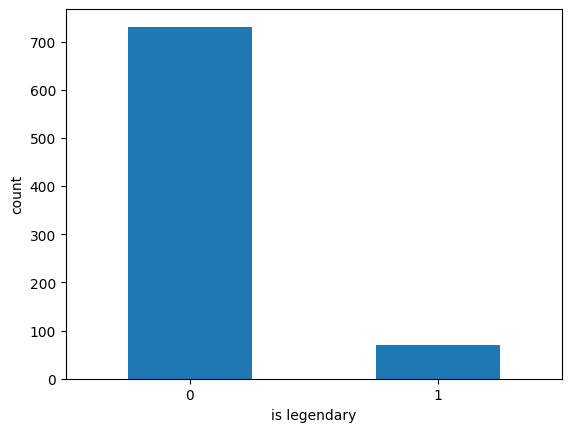

In [132]:
# Легендарных покемонов 8.74%, обычных – 91.26%
data = df['is_legendary'].value_counts()
data.plot(kind='bar', rot=0)
plt.xlabel('is legendary')
plt.ylabel('count')

In [133]:
df.nlargest(10, 'hp')

,name,base_total,percentage_male,type1,type2,height_m,weight_kg,capture_rate,base_egg_steps,experience_growth,base_happiness,hp,attack,defense,speed,generation,is_legendary
241,Blissey,540,0.0,normal,NaN,1.5,46.8,30,10240,800000,140,255,10,10,55,2,0
112,Chansey,450,0.0,normal,NaN,1.1,34.6,30,10240,800000,140,250,5,5,50,1,0
798,Guzzlord,570,NaN,dark,dragon,5.5,888.0,15,30720,1250000,0,223,101,53,43,7,1
717,Zygarde,708,NaN,dragon,ground,5.0,284.6,3,30720,1250000,0,216,100,121,85,6,1
201,Wobbuffet,405,50.0,psychic,NaN,1.3,28.5,45,5120,1000000,70,190,33,58,33,2,0
320,Wailord,500,50.0,water,NaN,14.5,398.0,60,10240,1640000,70,170,90,45,60,3,0
593,Alomomola,470,50.0,water,NaN,1.2,31.6,75,10240,800000,70,165,75,80,65,5,0
142,Snorlax,540,88.1,normal,NaN,2.1,460.0,25,10240,1250000,70,160,110,65,30,1,0
288,Slaking,670,50.0,normal,NaN,2.0,130.5,45,3840,1250000,70,150,160,100,100,3,0
425,Drifblim,498,50.0,ghost,flying,1.2,15.0,60,7680,1640000,70,150,80,44,80,4,0


In [134]:
df.nsmallest(10, ['hp', 'attack'])

,name,base_total,percentage_male,type1,type2,height_m,weight_kg,capture_rate,base_egg_steps,experience_growth,base_happiness,hp,attack,defense,speed,generation,is_legendary
291,Shedinja,236,NaN,bug,ghost,0.8,1.2,45,3840,600000,70,1,90,45,40,3,0
49,Diglett,265,50.0,ground,ground,NaN,NaN,255,5120,1000000,70,10,55,30,90,1,0
128,Magikarp,200,50.0,water,NaN,0.9,10.0,255,1280,1250000,70,20,10,55,80,1,0
212,Shuckle,505,50.0,bug,rock,0.6,20.5,190,5120,1059860,70,20,10,230,5,2,0
348,Feebas,200,50.0,water,NaN,0.6,7.4,255,5120,600000,70,20,15,20,80,3,0
438,Mime Jr.,310,50.0,psychic,fairy,0.6,13.0,145,6400,1000000,70,20,25,45,60,4,0
171,Pichu,205,50.0,electric,NaN,0.3,2.0,190,2560,1000000,70,20,40,15,60,2,0
354,Duskull,295,50.0,ghost,NaN,0.8,15.0,190,6400,800000,35,20,40,90,25,3,0
62,Abra,310,75.4,psychic,NaN,0.9,19.5,200,5120,1059860,70,25,20,15,90,1,0
80,Magnemite,325,NaN,electric,steel,0.3,6.0,190,5120,1000000,70,25,35,70,45,1,0


In [135]:
df.agg(['min', 'max'])

,name,base_total,percentage_male,type1,type2,height_m,weight_kg,capture_rate,base_egg_steps,experience_growth,base_happiness,hp,attack,defense,speed,generation,is_legendary
min,Abomasnow,180,0.0,bug,bug,0.1,0.1,100,1280,600000,0,1,5,5,5,1,0
max,Zygarde,780,100.0,water,water,14.5,999.9,90,30720,1640000,140,255,185,230,180,7,1


array([[<Axes: title={'center': 'hp'}>,
        <Axes: title={'center': 'attack'}>],
       [<Axes: title={'center': 'defense'}>,
        <Axes: title={'center': 'speed'}>]], dtype=object)

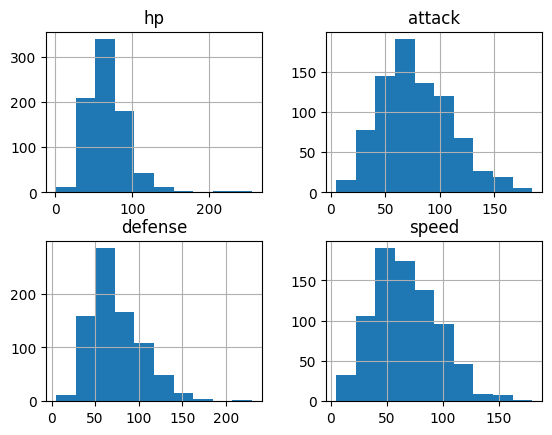

In [136]:
df[['hp', 'attack', 'defense', 'speed']].hist()

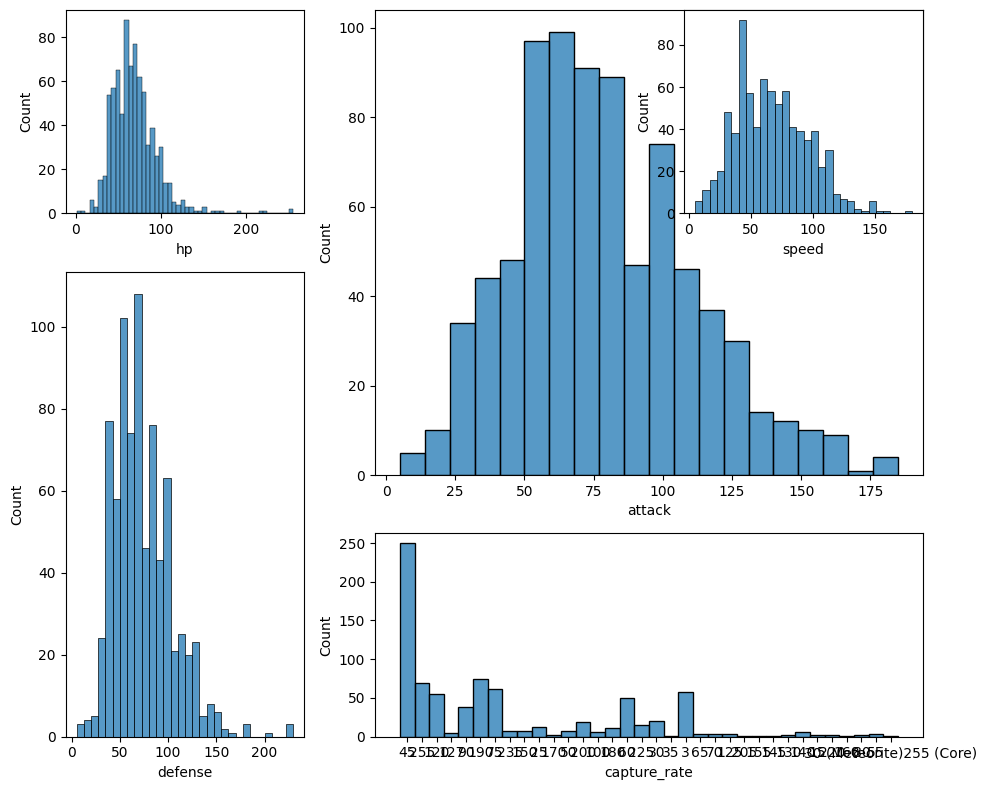

In [137]:
plt.figure(figsize=(10, 8))
plt.subplot(3, 3, 1)
sns.histplot(df['hp'], bins=50)
plt.subplot(3, 3, (2, 6))
sns.histplot(df['attack'], bins=20)
plt.subplot(3, 3, (4, 7))
sns.histplot(df['defense'], bins=30)
plt.subplot(3, 3, 3)
sns.histplot(df['speed'], bins=30)
plt.subplot(3, 3, (8, 9))
sns.histplot(df['capture_rate'], bins=8)
plt.tight_layout()

In [138]:
display(df.nlargest(10, 'attack')[['name', 'attack', 'is_legendary']])
display(df.nlargest(10, 'hp')[['name', 'hp', 'is_legendary']])
display(df.nlargest(10, 'defense')[['name', 'defense', 'is_legendary']])
display(df.nlargest(10, 'height_m')[['name', 'height_m', 'is_legendary']])
display(df.nlargest(10, 'weight_kg')[['name', 'weight_kg', 'is_legendary']])

,name,attack,is_legendary
213,Heracross,185,0
797,Kartana,181,1
382,Groudon,180,1
383,Rayquaza,180,1
444,Garchomp,170,0
353,Banette,165,0
408,Rampardos,165,0
474,Gallade,165,0
247,Tyranitar,164,0
256,Blaziken,160,0


,name,hp,is_legendary
241,Blissey,255,0
112,Chansey,250,0
798,Guzzlord,223,1
717,Zygarde,216,1
201,Wobbuffet,190,0
320,Wailord,170,0
593,Alomomola,165,0
142,Snorlax,160,0
288,Slaking,150,0
425,Drifblim,150,0


,name,defense,is_legendary
207,Steelix,230,0
212,Shuckle,230,0
305,Aggron,230,0
376,Regirock,200,1
712,Avalugg,184,0
79,Slowbro,180,0
90,Cloyster,180,0
410,Bastiodon,168,0
94,Onix,160,0
382,Groudon,160,1


,name,height_m,is_legendary
320,Wailord,14.5,0
207,Steelix,9.2,0
796,Celesteela,9.2,1
94,Onix,8.8,0
383,Rayquaza,7.0,1
129,Gyarados,6.5,0
349,Milotic,6.2,0
716,Yveltal,5.8,1
798,Guzzlord,5.5,1
482,Dialga,5.4,1


,name,weight_kg,is_legendary
789,Cosmoem,999.9,1
796,Celesteela,999.9,1
382,Groudon,950.0,1
749,Mudsdale,920.0,0
798,Guzzlord,888.0,1
486,Giratina,750.0,1
482,Dialga,683.0,1
375,Metagross,550.0,0
712,Avalugg,505.0,0
142,Snorlax,460.0,0


можно сказать, что среди легендарных покемонов нет однозначной доминации по конкретным показателя

In [139]:
#зато это можно сказать про общую «мощь» покемона
df.nlargest(20, 'base_total')['is_legendary'].sum()

np.int64(16)

Сильнейшие покемоны каждого поколения.

In [148]:
group_df = df.groupby('generation')

In [171]:
strongest_gen = df.loc[df.groupby('generation')['base_total'].idxmax()]
strongest_gen


,name,base_total,percentage_male,type1,type2,height_m,weight_kg,capture_rate,base_egg_steps,experience_growth,base_happiness,hp,attack,defense,speed,generation,is_legendary
149,Mewtwo,780,NaN,psychic,NaN,2.0,122.0,3,30720,1250000,0,106,150,70,140,1,1
247,Tyranitar,700,50.0,rock,dark,2.0,202.0,45,10240,1250000,35,100,164,150,71,2,0
383,Rayquaza,780,NaN,dragon,flying,7.0,206.5,45,30720,1250000,0,105,180,100,115,3,1
492,Arceus,720,NaN,normal,NaN,3.2,320.0,3,30720,1250000,0,120,120,120,120,4,1
645,Kyurem,700,NaN,dragon,ice,3.0,325.0,3,30720,1250000,0,125,120,90,95,5,1
717,Zygarde,708,NaN,dragon,ground,5.0,284.6,3,30720,1250000,0,216,100,121,85,6,1
790,Solgaleo,680,NaN,psychic,steel,3.4,230.0,45,30720,1250000,0,137,137,107,97,7,1


Среди покемонов каких типов больше всего легендарных?

In [178]:
display(df.groupby('type1')['is_legendary'].sum().sort_values(ascending=False))
df.groupby('type2')['is_legendary'].sum().sort_values(ascending=False)

type1
psychic     17
dragon       7
water        6
steel        6
electric     5
fire         5
rock         4
grass        4
dark         3
normal       3
bug          3
ground       2
ice          2
ghost        1
flying       1
fairy        1
poison       0
fighting     0
Name: is_legendary, dtype: int64

type2
flying      10
fairy        6
fighting     6
dragon       4
steel        4
psychic      4
grass        2
fire         2
ghost        2
ice          1
poison       1
water        1
ground       1
electric     1
normal       0
dark         0
rock         0
bug          0
Name: is_legendary, dtype: int64

In [187]:
group_df[['hp', 'attack', 'defense', 'speed', 'base_total', 'weight_kg', 'height_m']].mean()

,hp,attack,defense,speed,base_total,weight_kg,height_m
generation,,,,,,,
1,64.344371,74.529801,70.079470,70.152318,416.251656,45.827820,1.241353
2,70.980000,69.960000,71.790000,61.610000,413.180000,49.105000,1.163000
3,65.666667,77.185185,72.637037,63.577778,420.022222,67.077778,1.229630
4,73.102804,82.672897,76.168224,70.074766,451.177570,76.885047,1.133645
5,70.314103,80.557692,71.961538,66.519231,427.038462,52.402564,1.032051
6,71.111111,76.527778,73.555556,66.652778,437.611111,52.225352,1.092958
7,70.575000,84.637500,78.012500,64.037500,448.162500,98.300000,1.287342


In [207]:
cols = ['height_m', 'weight_kg']
display(df[cols].corr())
display(df[df['is_legendary'] == 1][cols].corr())
df[df['is_legendary'] == 0][cols].corr()


,height_m,weight_kg
height_m,1.000000,0.626551
weight_kg,0.626551,1.000000


,height_m,weight_kg
height_m,1.000000,0.608947
weight_kg,0.608947,1.000000


,height_m,weight_kg
height_m,1.000000,0.586261
weight_kg,0.586261,1.000000


<Axes: >

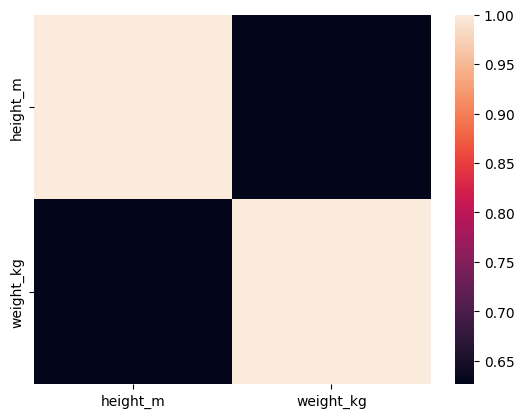

In [189]:
sns.heatmap(df[cols].corr())

<Axes: xlabel='weight_kg', ylabel='height_m'>

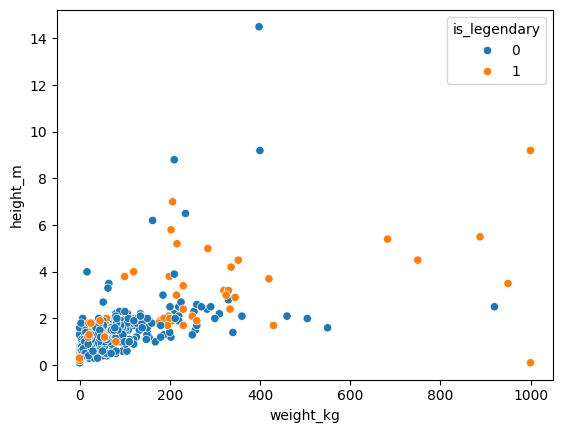

In [191]:
sns.scatterplot(data=df, x='weight_kg', y='height_m', hue='is_legendary')

<Axes: xlabel='weight_kg', ylabel='height_m'>

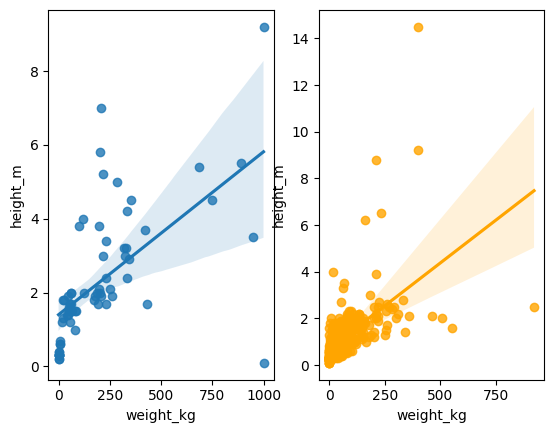

In [201]:
plt.figure()
plt.subplot(1, 2, 1)
sns.regplot(data=df[df['is_legendary'] == 1], x='weight_kg', y='height_m')
plt.subplot(1, 2, 2)
sns.regplot(data=df[df['is_legendary'] == 0], x='weight_kg', y='height_m', color='orange')

Есть ли связь веса и роста покемонов? Веса? – не особо

In [216]:
cols = ['hp', 'attack', 'defense',
        'speed', 'height_m', 'weight_kg',
        'is_legendary' , 'base_egg_steps', 'base_happiness']

corr_df = df[cols + ['base_total']].corr()['base_total'].sort_values(ascending=False)
corr_df

base_total        1.000000
attack            0.730134
defense           0.629620
hp                0.620624
speed             0.547666
height_m          0.535063
base_egg_steps    0.496466
is_legendary      0.485440
weight_kg         0.458111
base_happiness   -0.274795
Name: base_total, dtype: float64

Text(0.5, 1.0, 'Корреляция признаков с base_total')

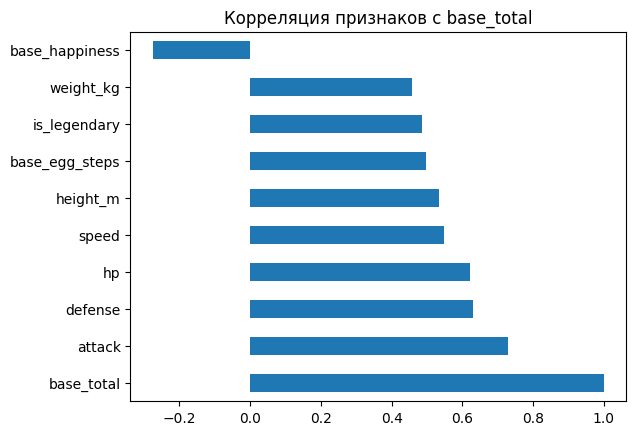

In [219]:
corr_df.plot(kind='barh')
plt.title('Корреляция признаков с base_total')